# 🧠 Quantum Readout Error Mitigation via Deep Learning
## Based on: *Kim et al., 2021 (arXiv:2112.03585)*

---

# 🎯 هدف پروژه

هدف این پروژه:

- کاهش خطای خوانش (Readout Error) در کیوبیت‌ها
  
- استفاده از یادگیری عمیق 
  
- بازسازی توزیع احتمال ایده‌آل از داده noisy

---

# ⚠️ تعریف مسئله

در کامپیوترهای کوانتومی واقعی:

- حالت واقعی کیوبیت‌ها ممکن است درست باشد
- اما هنگام اندازه‌گیری، خطا رخ می‌دهد

مثال:

| حالت واقعی | حالت اندازه‌گیری‌شده |
|------------|----------------------|
| 0          | 1 (با احتمال کم)     |
| 1          | 0 (با احتمال کم)     |

---

# 🧪 مدل ریاضی خطای خوانش

برای n کیوبیت:

\[
p_{\text{noisy}} = A \cdot p_{\text{ideal}}
\]

که:

- \(p_{\text{ideal}}\): توزیع واقعی
- \(p_{\text{noisy}}\): خروجی دستگاه
- \(A\): ماتریس خطای خوانش

---

# ⚙️ ساخت دیتاست (ایده اصلی مقاله)

برای آموزش شبکه عصبی:

## 1. تولید حالت های کوانتومی

برای هر کیوبیت از گیت:

\[
R_y(\theta)
\]

استفاده می‌کنیم.

---

## 🧠 Why \(R_y(\theta)\)؟

\[
R_y(\theta)|0\rangle =
\cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle
\]

✔ تولید برهمنهی واقعی  

✔ کنترل مستقیم روی احتمال  

✔ مناسب برای sampling فضای حالت‌ها  

---

## ❌ چرا از \(R_z\) استفاده نمی‌کنیم؟

\[
R_z(\theta)|0\rangle = e^{-i\theta/2}|0\rangle
\]

- فقط فاز تغییر می‌کند

- احتمال‌ها تغییر نمی‌کنند

---

# 🔬 مثال برای 1 کیوبیت

### انتخاب زاویه:
```python
theta = 1.2
```
state: 
|ψ⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩

probabilities:

p_ideal = [cos²(θ/2), sin²(θ/2)]


# 🔬 مثال برای 2 کیوبیت

مدار:

qubit 0 → R_y(θ1)

qubit 1 → R_y(θ2)

state:

∣ψ⟩=(cosa∣0⟩+sina∣1⟩)⊗(cosb∣0⟩+sinb∣1⟩)

توزیع احتمال ایده‌آل:

p_ideal = [p00, p01, p10, p11]

### 📊 اعمال نویز خوانش (Readout Error)

در این مرحله:

✔ حالت تغییر نمی‌کند

✔ فقط نتیجه اندازه گیری اشتباه می‌شود

exp: ideal distribution

p_ideal = [0.70, 0.10, 0.15, 0.05]

after musuerment noise (10% flip chance):

p_noisy = [0.60, 0.18, 0.12, 0.10]


### 🧠 نکته مهم 

✔ نویز از گیت نمی‌آید

✔ نویز از اندازه گیری می‌آید

✔ Ry فقط برای تولید حالت متنوع استفاده می‌شود

🚀 جمع‌بندی

این روش یاد می‌گیرد:

fθ(p_noisy​)≈p_ideal



و در عمل:

✔ معکوس ماتریس خطا را تقریب می‌زند

✔ بدون نیاز به calibration پیچیده

✔ قابل تعمیم به چند کیوبیت

Independent classical readout error

# 2 Qubits

In [22]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import numpy as np
from itertools import product

In [23]:
#### تعریف مدل نویز خوانش
# احتمال خطای خوانش برای هر کیوبیت
"""
    p00: احتمال درست خواندن 0
    p11: احتمال درست خواندن 1
    
    error_matrix = [
        [p00, 1 - p11],  # واقعی 0 -> دیده شده 0/1
        [1 - p00, p11]   # واقعی 1 -> دیده شده 0/1
    ]
"""

readout_error = ReadoutError([
    [0.90, 0.10],  # 0 -> 0 / 1
    [0.15, 0.85]   # 1 -> 0 / 1
])
noise_model = NoiseModel()
noise_model.add_readout_error(readout_error, [0])
noise_model.add_readout_error(readout_error, [1])
### Create simulator with/without noise
ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise_model)
### Cretae 2-qubits circiut with Ry
def build_circuit(theta1, theta2):
    qc = QuantumCircuit(2, 2)
    qc.ry(theta1, 0)
    qc.ry(theta2, 1)
    qc.measure([0,1], [0,1])
    return qc 
### convert counts → probability vector
def counts_to_probs(counts):
    probs = np.zeros(4)
    for bitstring, count in counts.items():
        idx = int(bitstring, 2)
        probs[idx] = count
    probs = probs / np.sum(probs)
    return probs
#-----------------------------------------
### claculating p_ideal
def get_ideal(theta1, theta2, shots=2048):
    qc = build_circuit(theta1, theta2)
    result = ideal_sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs(counts)
#------------------------------------------
#### calculating p_noisy
def get_noisy(theta1, theta2, shots=2048):
    qc = build_circuit(theta1, theta2)   
    result = noisy_sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    return counts_to_probs(counts)

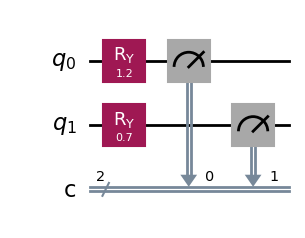

In [24]:
# مثال زاویه
theta1 = 1.2
theta2 = 0.7

qc = build_circuit(theta1, theta2)
# رسم مدار
qc.draw("mpl")

In [51]:
# example of applying stochastic matrix : A
# A2 = A ⊗ A
# p_noisy=A2.p_ideal
import numpy as np

A = np.array([
    [0.90, 0.10],
    [0.15, 0.85]
])

# for to qubits: 
A2 = np.kron(A, A)

p_ideal = np.array([0.8, 0.1, 0.1, 0.0])

p_noisy = A2 @ p_ideal
print('A: \n', A)

print('A2: \n', A2)
print('p_noisy: \n', p_noisy)

A: 
 [[0.9  0.1 ]
 [0.15 0.85]]
A2: 
 [[0.81   0.09   0.09   0.01  ]
 [0.135  0.765  0.015  0.085 ]
 [0.135  0.015  0.765  0.085 ]
 [0.0225 0.1275 0.1275 0.7225]]
p_noisy: 
 [0.666  0.186  0.186  0.0435]


In [25]:
### Gnerate complete dataset:
def generate_dataset(num_samples=2000):
    
    X = []
    Y = []
    for _ in range(num_samples):
        # sample random angles
        theta1 = np.random.uniform(0, np.pi)
        theta2 = np.random.uniform(0, np.pi)
        # ideal
        p_ideal = get_ideal(theta1, theta2)
        # noisy
        p_noisy = get_noisy(theta1, theta2)
        X.append(p_noisy)
        Y.append(p_ideal)
    
    return np.array(X), np.array(Y)

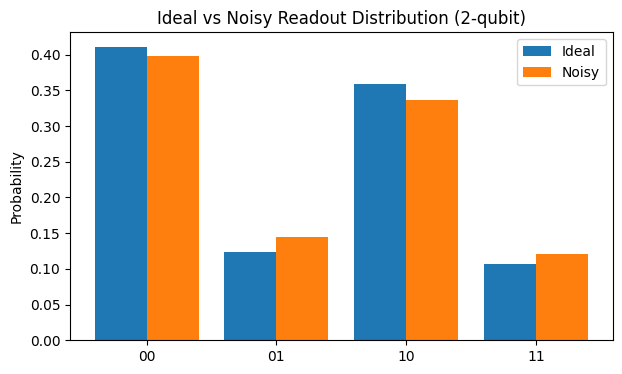

In [37]:
import matplotlib.pyplot as plt
import numpy as np

theta1, theta2 = 1.0, 1.5

p_ideal = get_ideal(theta1, theta2)
p_noisy = get_noisy(theta1, theta2)

labels = ["00", "01", "10", "11"]
x = np.arange(len(labels))
# print(x)

plt.figure(figsize=(7,4))

plt.bar(x - 0.2, p_ideal, width=0.4, label="Ideal")
plt.bar(x + 0.2, p_noisy, width=0.4, label="Noisy")

plt.xticks(x, labels)
plt.ylabel("Probability")
plt.title("Ideal vs Noisy Readout Distribution (2-qubit)")
plt.legend()
plt.show()

In [27]:
#### Generate datasets
X, Y = generate_dataset(1000)

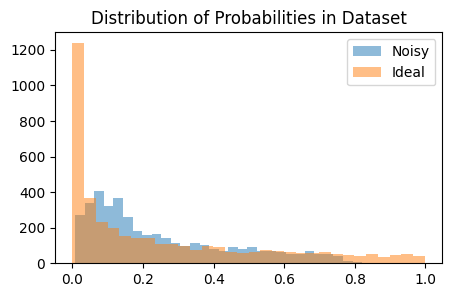

In [31]:
### Put all probabilities in a list to plot a histogram
### 1000 sample * 4 values = 4000  data
# p00 = cos^2(θ1/2)cos^2(θ2/2)

plt.figure(figsize=(5,3))
plt.hist(X.flatten(), bins=30, alpha=0.5, label="Noisy")
plt.hist(Y.flatten(), bins=30, alpha=0.5, label="Ideal")

plt.title("Distribution of Probabilities in Dataset")
plt.legend()
plt.show()

In [32]:
print("Max ideal:", Y.max())
print("Max noisy:", X.max())
## expected! since ideal prob can be 1 
### after noisy measurement (according to noisy model) 
# [0.90, 0.10]
# [0.15, 0.85]
# P(correct) ≈ 0.9 × 0.9 ≈ 0.81

### So ML model should learn 0.8 --> 1 (and 0.1 --> 0)


Max ideal: 0.998046875
Max noisy: 0.82080078125


In [39]:
print("Sample noisy  :", X[0])
print("Sample ideal  :", Y[0])
print("Sum noisy     :", np.sum(X[0]))
print("Sum ideal     :", np.sum(Y[0]))

Sample noisy  : [0.09179688 0.14599609 0.28320312 0.47900391]
Sample ideal  : [0.03369141 0.06445312 0.28125    0.62060547]
Sum noisy     : 1.0
Sum ideal     : 1.0


## MLP and Training

In [52]:
import torch
import torch.nn as nn
# from torch.optim import optimizer
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [53]:
### Convert datasets to tensor
# X = p_noisy, Y = p_ideal
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)
dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [54]:
# MLP Defination:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 4),
            nn.Softmax(dim=1)
        )   
    def forward(self, x):
        return self.net(x)
# loss (KL Divergence)
model = MLP()
criterion = nn.KLDivLoss(reduction="batchmean")   # input = log probabilities, target = probabilities
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [55]:
### Training loop 

epochs = 100
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    
    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        # forward
        preds = model(x_batch)
        # KL loss needs log-prob
        loss = criterion(torch.log(preds + 1e-8), y_batch)
        # backward
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/100, Loss: 0.601220
Epoch 2/100, Loss: 0.520247
Epoch 3/100, Loss: 0.307768
Epoch 4/100, Loss: 0.104221
Epoch 5/100, Loss: 0.038262
Epoch 6/100, Loss: 0.027546
Epoch 7/100, Loss: 0.026502
Epoch 8/100, Loss: 0.025645
Epoch 9/100, Loss: 0.025115
Epoch 10/100, Loss: 0.024824
Epoch 11/100, Loss: 0.024498
Epoch 12/100, Loss: 0.024370
Epoch 13/100, Loss: 0.024091
Epoch 14/100, Loss: 0.023436
Epoch 15/100, Loss: 0.023084
Epoch 16/100, Loss: 0.023352
Epoch 17/100, Loss: 0.022159
Epoch 18/100, Loss: 0.023374
Epoch 19/100, Loss: 0.021981
Epoch 20/100, Loss: 0.021559
Epoch 21/100, Loss: 0.021585
Epoch 22/100, Loss: 0.021802
Epoch 23/100, Loss: 0.020633
Epoch 24/100, Loss: 0.020601
Epoch 25/100, Loss: 0.019928
Epoch 26/100, Loss: 0.019163
Epoch 27/100, Loss: 0.018882
Epoch 28/100, Loss: 0.018215
Epoch 29/100, Loss: 0.017468
Epoch 30/100, Loss: 0.016997
Epoch 31/100, Loss: 0.016338
Epoch 32/100, Loss: 0.015729
Epoch 33/100, Loss: 0.015373
Epoch 34/100, Loss: 0.014988
Epoch 35/100, Loss: 0.0

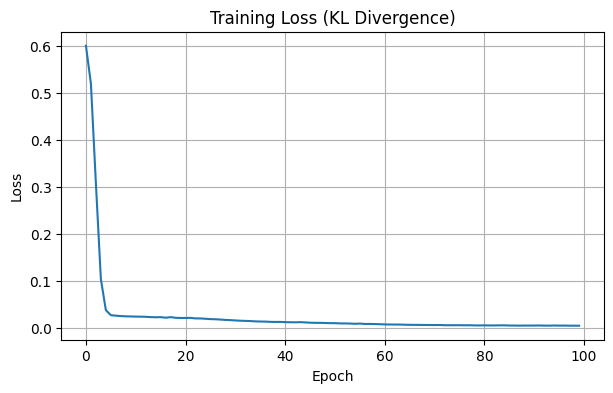

In [56]:
## plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.title("Training Loss (KL Divergence)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [57]:
## test 
model.eval()

with torch.no_grad():
    x_test = X_tensor[0].unsqueeze(0)
    y_pred = model(x_test)

print("Noisy input :", X_tensor[0].numpy())
print("Prediction  :", y_pred.numpy())
print("Ideal target:", Y_tensor[0].numpy())

Noisy input : [0.09179688 0.1459961  0.28320312 0.4790039 ]
Prediction  : [[0.0348515  0.08929266 0.2604686  0.61538726]]
Ideal target: [0.03369141 0.06445312 0.28125    0.62060547]


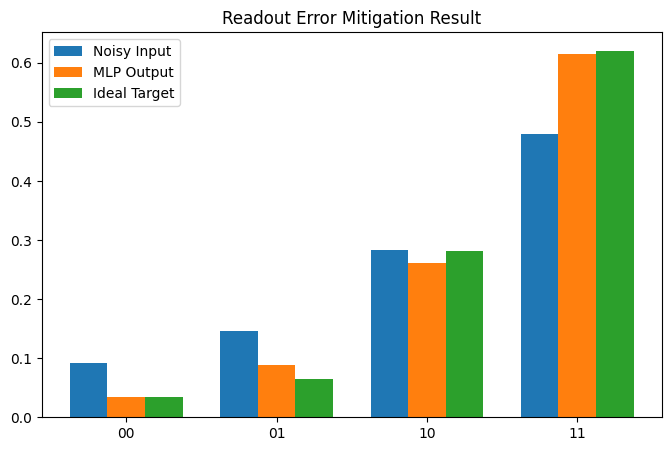

In [60]:
### compare 

import numpy as np

labels = ["00", "01", "10", "11"]
x = np.arange(4)

pred = y_pred.numpy().flatten()
ideal = Y_tensor[0].numpy()
noisy = X_tensor[0].numpy()

plt.figure(figsize=(8,5))

plt.bar(x - 0.25, noisy, width=0.25, label="Noisy Input")
plt.bar(x, pred, width=0.25, label="MLP Output")
plt.bar(x + 0.25, ideal, width=0.25, label="Ideal Target")

plt.xticks(x, labels)
plt.title("Readout Error Mitigation Result")
plt.legend()
plt.show()